In [2]:
from casadi import *
import numpy as np

In [ ]:
x = MX.sym('x',2);  # Two states (position, velocity)
A = DM([[0,1], [-1,0]]) # A matrix of armonic oscillator
rhs = mtimes(A,x)

te = 10 # simulation end time
dt = 0.01 # how often to save results of state trajectory
tn = np.linspace(0., te, int(te/dt))

print(rhs)

ode = {}         # ODE declaration
ode['x']   = x   # states
ode['ode'] = rhs # right-hand side

# Construct a Function that integrates over tn
# if the second float parameter is a scalar, it is treated as the end time of the simulation (tf)
# if it is an array, each value an instant in which the output is recorded
# https://web.casadi.org/python-api/#integrator
# this is not very clear from the docs
opts = {}
F = integrator('F','cvodes',ode, 0, tn ,opts)


# Integrate with initial conditions x=[0;1]
res = F(x0=[0,1])

print(res)

mac(
[[0, 1], 
 [-1, 0]],x,zeros(2x1))


RuntimeError: Error in Function::call for 'F' [CvodesInterface] at .../casadi/core/function.cpp:1466:
.../casadi/core/function_internal.hpp:1130: FunctionInternal::index_in: could not find entry "r". Available names are: [x0, z0, p, u, adj_xf, adj_zf, adj_qf].

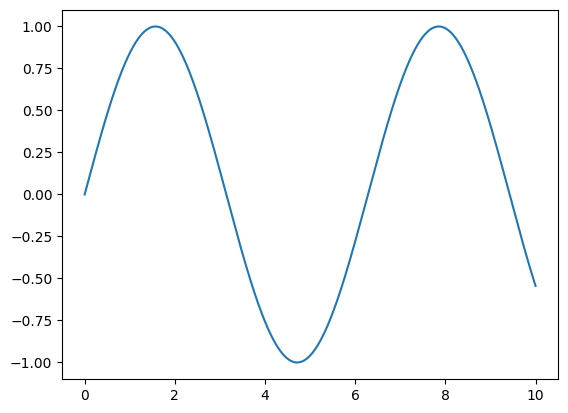

In [3]:
import matplotlib.pyplot as plt

x = res['xf'][0,:].T
fig, ax = plt.subplots()
ax.plot(tn, x)